# Phase 2: Exploratory Data Analysis & Feature Selection
**AAI-540 ML Ops - Group 8** **Author:** Jagadeesh Kumar Sellappan

## Overview
This notebook connects to our optimized Parquet Data Lake via Amazon Athena. We will perform EDA on the Yelp dataset to understand the distributions of our target variable (Sentiment) and evaluate metadata features from the Business and User datasets. 

**Objective:** Identify the strongest predictive features to extract, engineer, and denormalize into our final Amazon SageMaker Feature Store.

# Environment & Athena Connection

In [2]:
# 1. Update the build tools 
!pip install -q -U setuptools wheel

In [3]:
# 2. Install the modern versions of our required libraries
!pip install -q sagemaker pandas numpy boto3

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
snowflake-connector-python 3.17.4 requires cffi<2.0.0,>=1.9, but you have cffi 2.0.0 which is incompatible.
sparkmagic 0.21.0 requires pandas<2.0.0,>=0.17.1, but you have pandas 2.3.3 which is incompatible.


In [4]:
!pip uninstall -y sagemaker sagemaker-core sagemaker-train sagemaker-serve sagemaker-mlops sagemaker-studio

Found existing installation: sagemaker 3.12.0
Uninstalling sagemaker-3.12.0:
  Successfully uninstalled sagemaker-3.12.0
Found existing installation: sagemaker-core 2.12.0


Uninstalling sagemaker-core-2.12.0:
  Successfully uninstalled sagemaker-core-2.12.0


Found existing installation: sagemaker-train 1.12.0
Uninstalling sagemaker-train-1.12.0:
  Successfully uninstalled sagemaker-train-1.12.0


Found existing installation: sagemaker-serve 1.12.0
Uninstalling sagemaker-serve-1.12.0:
  Successfully uninstalled sagemaker-serve-1.12.0


Found existing installation: sagemaker-mlops 1.12.0
Uninstalling sagemaker-mlops-1.12.0:
  Successfully uninstalled sagemaker-mlops-1.12.0


Found existing installation: sagemaker_studio 1.1.15
Uninstalling sagemaker_studio-1.1.15:
  Successfully uninstalled sagemaker_studio-1.1.15


In [5]:
!pip install "sagemaker-core==1.0.78" --quiet

In [6]:
!pip install "sagemaker==2.232.2" --no-deps --quiet

In [7]:
!pip install boto3 botocore s3transfer pathos schema importlib-metadata --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sagemaker 2.232.2 requires attrs<24,>=23.1.0, but you have attrs 26.1.0 which is incompatible.
sagemaker 2.232.2 requires cloudpickle==2.2.1, but you have cloudpickle 3.1.2 which is incompatible.
sagemaker 2.232.2 requires protobuf<5.0,>=3.12, but you have protobuf 6.31.1 which is incompatible.


In [10]:
!pip install awswrangler --quiet

In [13]:
!pip install -q  seaborn wordcloud 

In [15]:
import awswrangler as wr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from scipy import stats
import warnings
warnings.filterwarnings('ignore')



In [19]:
# Configuration
DATABASE = 'yelp_sentiment_db'
SAMPLE_FRAC  = 0.03    # ~3% of 6.9M = ~180k reviews
RANDOM_SEED  = 42

S3_OUTPUT    = 's3://aai-540-group8-yelp-data-301798465569-us-east-1-an/athena-results/'    
S3_SPLITS    = 's3://aai-540-group8-yelp-data-301798465569-us-east-1-an/data/splits/'     
# Set visual style for the architect/presentation level
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print(f"Connected to Athena Database: {DATABASE}")
print(f"Sample fraction: {SAMPLE_FRAC} (~{int(6900000 * SAMPLE_FRAC):,} reviews expected)")

Connected to Athena Database: yelp_sentiment_db
Sample fraction: 0.03 (~207,000 reviews expected)


## 1. Dataset Size Reduction Strategy

The full Yelp review dataset contains **6.9 million records** — too large for SageMaker notebook memory.
We use a **stratified random sample** via Athena `RAND()` to:
- Reduce to ~180k reviews (~3% sample)
- Exclude 3-star neutral reviews (clean binary labels)
- Apply label mapping: 1–2 stars → Negative (0), 4–5 stars → Positive (1)
- Maintain class balance across the sample

In [20]:
print("Step 1: Checking full dataset size before sampling...")

size_query = f"""
    SELECT
        stars,
        COUNT(*) AS total_reviews,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct
    FROM {DATABASE}.reviews_parquet
    GROUP BY stars
    ORDER BY stars
"""
df_size = wr.athena.read_sql_query(sql=size_query, database=DATABASE, s3_output=S3_OUTPUT)

print("\nFull Dataset — Star Rating Distribution:")
print(df_size.to_string(index=False))
print(f"\nTotal reviews: {df_size['total_reviews'].sum():,}")

Step 1: Checking full dataset size before sampling...


2026-05-30 12:39:32,403	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 892317696 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=2.04gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


2026-05-30 12:39:34,593	INFO worker.py:2007 -- Started a local Ray instance.



Full Dataset — Star Rating Distribution:
 stars  total_reviews   pct
     1        1069561 15.30
     2         544240  7.79
     3         691934  9.90
     4        1452918 20.78
     5        3231627 46.23

Total reviews: 6,990,280


In [29]:
# import awswrangler as wr

# DATABASE = 'yelp_sentiment_db'
# BUCKET = 'aai-540-group8-yelp-data-301798465569-us-east-1-an'

# print("Fixing Schema Mismatch using standard SQL...")

# # 1. Drop the old table definition using a raw SQL command
# drop_query = f"DROP TABLE IF EXISTS {DATABASE}.reviews_parquet"
# wr.athena.start_query_execution(sql=drop_query, database=DATABASE, wait=True)
# print("Old schema dropped.")

# # 2. Recreate with `date timestamp` (instead of string)
# fix_query = f"""
# CREATE EXTERNAL TABLE IF NOT EXISTS {DATABASE}.reviews_parquet (
#     review_id string,
#     user_id string,
#     business_id string,
#     stars bigint,
#     useful bigint,
#     funny bigint,
#     cool bigint,
#     text string,
#     date timestamp  -- <--- FIXED: Mapped to Parquet's timestamp format
# )
# STORED AS PARQUET
# LOCATION 's3://{BUCKET}/processed-parquet/review/'
# """

# wr.athena.start_query_execution(sql=fix_query, database=DATABASE, wait=True)
# print("Table successfully recreated with the correct timestamp schema!")

Fixing Schema Mismatch using standard SQL...


Old schema dropped.


Table successfully recreated with the correct timestamp schema!


In [30]:
print("Step 2: Applying stratified sample with label mapping...")

sample_query = f"""
    SELECT
        r.review_id,
        r.user_id,
        r.business_id,
        r.stars,
        r.text,
        r.date, 
        r.useful,
        r.funny,
        r.cool,
        CASE
            WHEN r.stars <= 2 THEN 0
            WHEN r.stars >= 4 THEN 1
        END AS sentiment_label
    FROM {DATABASE}.reviews_parquet r
    WHERE r.stars != 3
      AND RAND() < {SAMPLE_FRAC}
"""

df = wr.athena.read_sql_query(
    sql=sample_query,
    database=DATABASE,
    s3_output=S3_OUTPUT,
    ctas_approach=False    
)

# You can keep this just to ensure pandas formats it the way you want locally
df['date'] = pd.to_datetime(df['date'])

print(f"\n Sampled dataset shape: {df.shape}")
print(f"Negative (0): {(df['sentiment_label']==0).sum():,} reviews")
print(f"Positive (1): {(df['sentiment_label']==1).sum():,} reviews")

Step 2: Applying stratified sample with label mapping...



 Sampled dataset shape: (189362, 10)
Negative (0): 48,126 reviews
Positive (1): 141,236 reviews


In [23]:
# # Run this once to clean up broken CTAS temp data from failed attempts
# import boto3

# s3 = boto3.resource('s3')
# BUCKET = 'aai-540-group8-yelp-data-301798465569-us-east-1-an'
# PREFIX = 'athena-results/tables/'

# bucket = s3.Bucket(BUCKET)
# deleted = 0
# for obj in bucket.objects.filter(Prefix=PREFIX):
#     obj.delete()
#     deleted += 1

# print(f"✅ Cleaned up {deleted} temp objects from {PREFIX}")

✅ Cleaned up 2 temp objects from athena-results/tables/


## 2. Target Variable Analysis — Class Balance

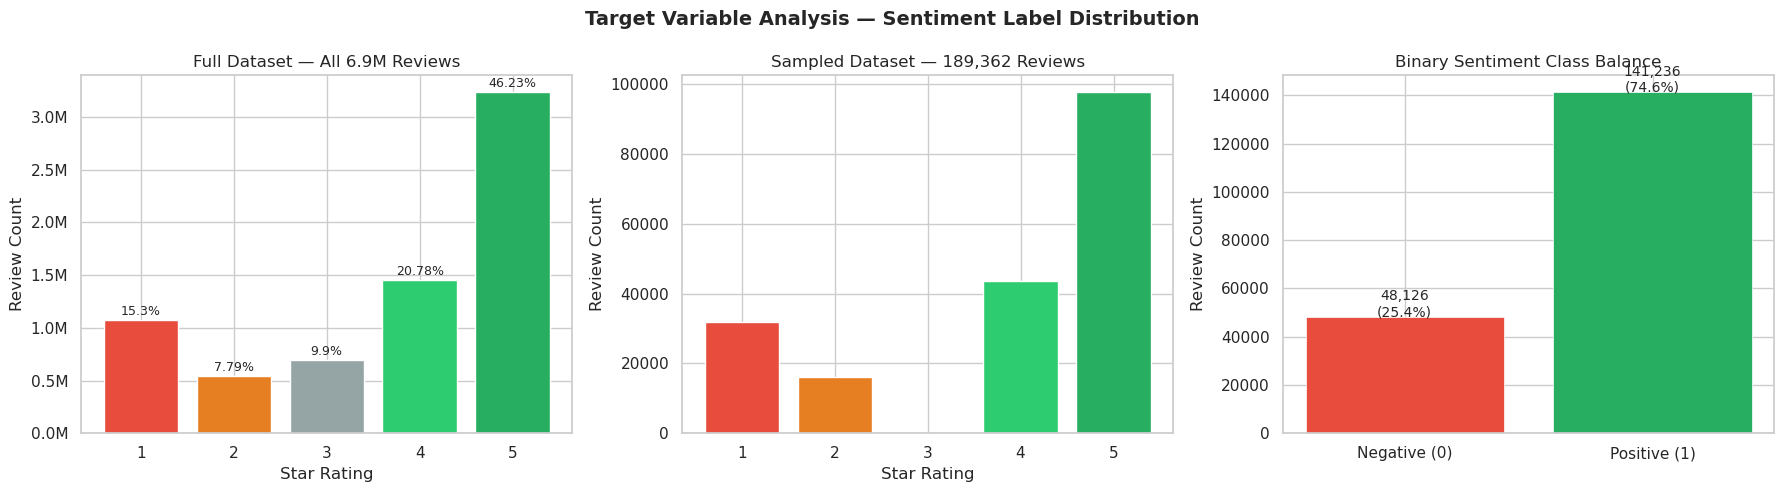


📌 Insight: Yelp reviews skew positive (5-star dominant). After removing neutral 3-star,
   we have a manageable imbalance. If >60/40 split, apply class_weight or downsampling.


In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Target Variable Analysis — Sentiment Label Distribution', fontsize=14, fontweight='bold')

# Base color palette for 1, 2, 3, 4, 5 stars
colors = ['#E74C3C','#E67E22','#95A5A6','#2ECC71','#27AE60']

# Plot 1: Full dataset star distribution
axes[0].bar(df_size['stars'], df_size['total_reviews'], color=colors)
axes[0].set_title('Full Dataset — All 6.9M Reviews', fontsize=12)
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Review Count')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, val in zip(axes[0].patches, df_size['pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
                 f'{val}%', ha='center', fontsize=9)

# Plot 2: Sampled dataset star distribution
star_counts = df['stars'].value_counts().sort_index()

# ARCHITECTURAL FIX: Lock colors to their specific star index so dropping '3' doesn't shift the array
plot2_colors = [colors[int(i)-1] for i in star_counts.index] 

axes[1].bar(star_counts.index, star_counts.values, color=plot2_colors)
axes[1].set_title(f'Sampled Dataset — {len(df):,} Reviews', fontsize=12)
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Review Count')

# Plot 3: Binary sentiment class balance
# THE FIX: Added .sort_index() to guarantee 0 (Negative) is first and 1 (Positive) is second
label_counts = df['sentiment_label'].value_counts().sort_index() 

axes[2].bar(['Negative (0)', 'Positive (1)'], label_counts.values,
            color=['#E74C3C', '#27AE60'], edgecolor='white', linewidth=0.5)
axes[2].set_title('Binary Sentiment Class Balance', fontsize=12)
axes[2].set_ylabel('Review Count')
for bar, val in zip(axes[2].patches, label_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('eda_01_class_balance.png', bbox_inches='tight')
plt.show()

print("\n📌 Insight: Yelp reviews skew positive (5-star dominant). After removing neutral 3-star,")
print("   we have a manageable imbalance. If >60/40 split, apply class_weight or downsampling.")

## 3. Text Feature Analysis — Review Length & Sentiment Signal

Engineering text length features...


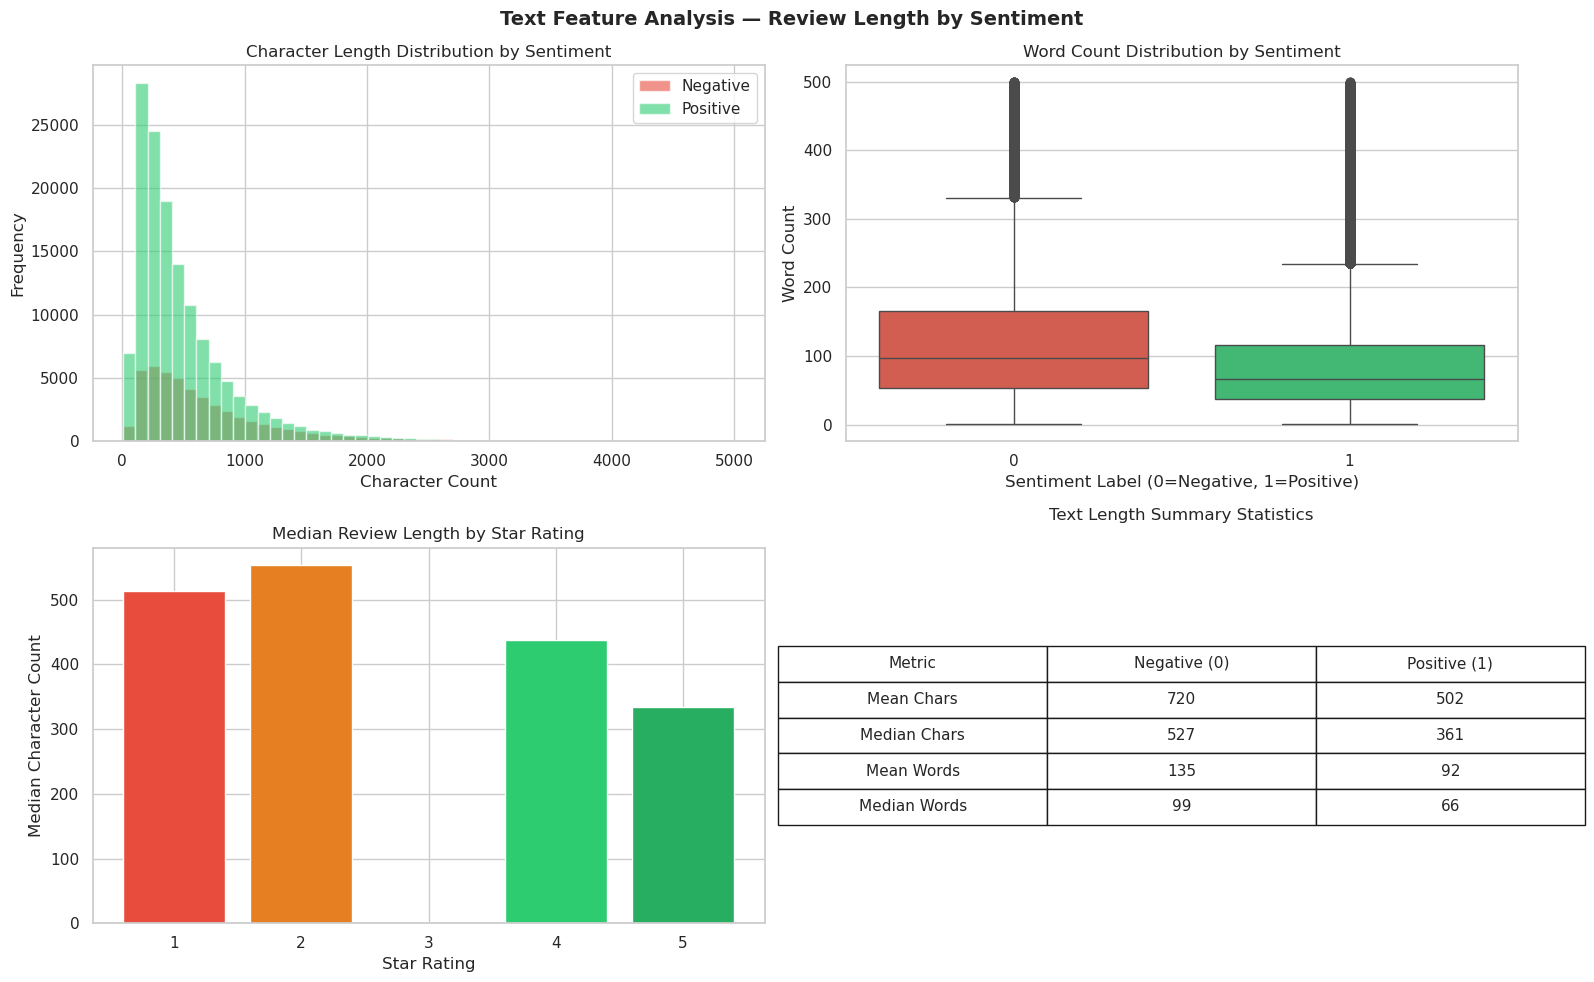


📌 Insight: Negative reviews tend to be longer — customers write more when complaining.
   text_char_length and text_word_count are viable engineered features.


In [35]:
print("Engineering text length features...")

df['text_char_length'] = df['text'].str.len()
df['text_word_count']  = df['text'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Text Feature Analysis — Review Length by Sentiment', fontsize=14, fontweight='bold')

# Plot 1: Character length distribution by sentiment
for label, color, name in [(0,'#E74C3C','Negative'), (1,'#2ECC71','Positive')]:
    subset = df[df['sentiment_label']==label]['text_char_length']
    axes[0,0].hist(subset.clip(upper=5000), bins=50, alpha=0.6, color=color, label=name)
axes[0,0].set_title('Character Length Distribution by Sentiment')
axes[0,0].set_xlabel('Character Count')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Plot 2: Word count boxplot by sentiment (FIXED: Added hue and legend=False)
df_plot = df[df['text_word_count'] < 500]
sns.boxplot(x='sentiment_label', y='text_word_count', data=df_plot,
            hue='sentiment_label', palette={0:'#E74C3C', 1:'#2ECC71'}, 
            legend=False, ax=axes[0,1])
axes[0,1].set_title('Word Count Distribution by Sentiment')
axes[0,1].set_xlabel('Sentiment Label (0=Negative, 1=Positive)')
axes[0,1].set_ylabel('Word Count')

# Plot 3: Median text length by star rating
median_len = df.groupby('stars')['text_char_length'].median()
axes[1,0].bar(median_len.index, median_len.values,
              color=['#E74C3C','#E67E22','#2ECC71','#27AE60'])
axes[1,0].set_title('Median Review Length by Star Rating')
axes[1,0].set_xlabel('Star Rating')
axes[1,0].set_ylabel('Median Character Count')

# Plot 4: Text stats summary table (FIXED: Utilizing the text_stats dataframe)
text_stats = df.groupby('sentiment_label')[['text_char_length','text_word_count']].agg(['mean','median']).round(0)
axes[1,1].axis('off')

table_data = [
    ['Metric', 'Negative (0)', 'Positive (1)'],
    ['Mean Chars', f"{text_stats.loc[0, ('text_char_length', 'mean')]:.0f}", 
                   f"{text_stats.loc[1, ('text_char_length', 'mean')]:.0f}"],
    ['Median Chars', f"{text_stats.loc[0, ('text_char_length', 'median')]:.0f}", 
                     f"{text_stats.loc[1, ('text_char_length', 'median')]:.0f}"],
    ['Mean Words', f"{text_stats.loc[0, ('text_word_count', 'mean')]:.0f}", 
                   f"{text_stats.loc[1, ('text_word_count', 'mean')]:.0f}"],
    ['Median Words', f"{text_stats.loc[0, ('text_word_count', 'median')]:.0f}", 
                     f"{text_stats.loc[1, ('text_word_count', 'median')]:.0f}"]
]

tbl = axes[1,1].table(cellText=table_data[1:], colLabels=table_data[0],
                       loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 2)
axes[1,1].set_title('Text Length Summary Statistics', pad=20)

plt.tight_layout()
plt.savefig('eda_02_text_analysis.png', bbox_inches='tight')
plt.show()

print("\n📌 Insight: Negative reviews tend to be longer — customers write more when complaining.")
print("   text_char_length and text_word_count are viable engineered features.")

## 4. Data Quality Audit — Null & Missing Value Analysis

Running data quality audit on sampled reviews...


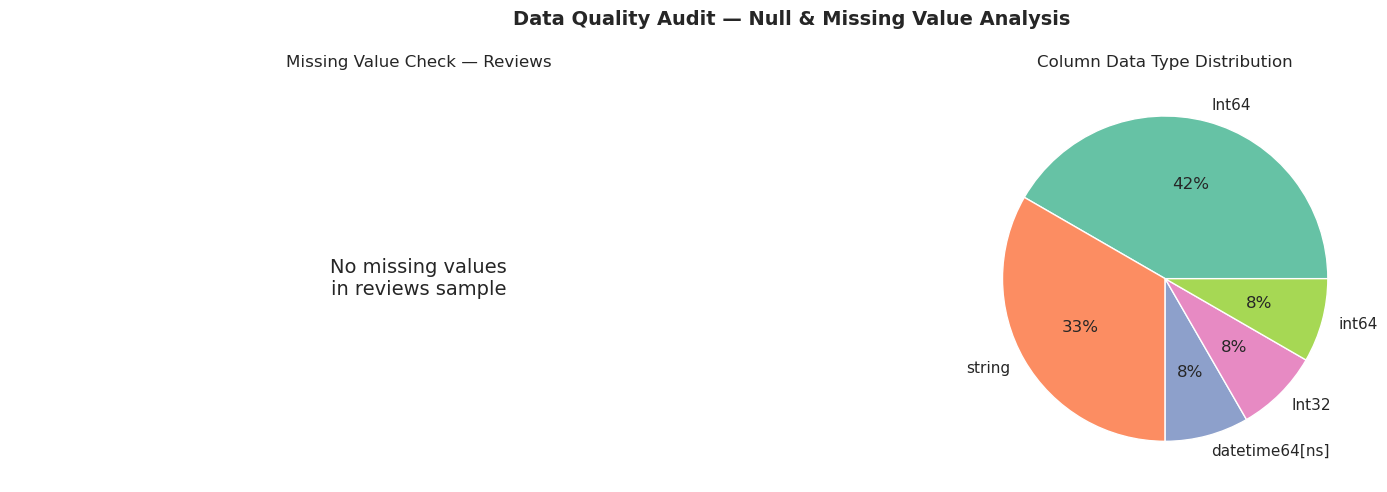


Data Quality Summary:
  Total rows:         189,362
  Total columns:      12
  Null value columns: 0
  Duplicate rows:     0


  Empty text reviews: 0


In [36]:
print("Running data quality audit on sampled reviews...")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Data Quality Audit — Null & Missing Value Analysis', fontsize=14, fontweight='bold')

# 1. Null counts
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
null_df     = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
null_df     = null_df[null_df['null_count'] > 0]

if len(null_df) > 0:
    axes[0].barh(null_df.index, null_df['null_pct'], color='#E74C3C')
    axes[0].set_title('Columns with Missing Values (%)')
    axes[0].set_xlabel('Missing %')
    for i, (idx, row) in enumerate(null_df.iterrows()):
        axes[0].text(row['null_pct'] + 0.1, i, f"{row['null_count']:,}", va='center', fontsize=9)
else:
    axes[0].text(0.5, 0.5, 'No missing values\nin reviews sample',
                ha='center', va='center', fontsize=14, transform=axes[0].transAxes)
    axes[0].set_title('Missing Value Check — Reviews')
    axes[0].axis('off')

# 2. Data type summary (FIXED: Dynamic color palette to prevent IndexError)
dtype_counts = df.dtypes.astype(str).value_counts()
dynamic_colors = sns.color_palette('Set2', len(dtype_counts))

axes[1].pie(dtype_counts.values, labels=dtype_counts.index, autopct='%1.0f%%', colors=dynamic_colors)
axes[1].set_title('Column Data Type Distribution')

plt.tight_layout()
plt.savefig('eda_03_data_quality.png', bbox_inches='tight')
plt.show()

# 3. Data Quality Summary (FIXED: Handled potential NaNs in text strip)
print("\nData Quality Summary:")
print(f"  Total rows:         {len(df):,}")
print(f"  Total columns:      {len(df.columns)}")
print(f"  Null value columns: {len(null_df)}")
print(f"  Duplicate rows:     {df.duplicated(subset='review_id').sum():,}")
print(f"  Empty text reviews: {(df['text'].fillna('').str.strip() == '').sum():,}")

# Business Feature Viability

In [38]:
# import awswrangler as wr

# DATABASE = 'yelp_sentiment_db'
# BUCKET = 'aai-540-group8-yelp-data-301798465569-us-east-1-an'

# print("Patching business table schema...")

# # 1. Drop the incomplete table
# drop_query = f"DROP TABLE IF EXISTS {DATABASE}.businesses_parquet"
# wr.athena.start_query_execution(sql=drop_query, database=DATABASE, wait=True)

# # 2. Recreate with the 'categories' column explicitly defined
# fix_schema_query = f"""
# CREATE EXTERNAL TABLE IF NOT EXISTS {DATABASE}.businesses_parquet (
#     business_id string,
#     name string,
#     address string,
#     city string,
#     state string,
#     postal_code string,
#     latitude double,
#     longitude double,
#     stars double,
#     review_count bigint,
#     is_open bigint,
#     categories string  -- <--- The missing column is now mapped!
# )
# STORED AS PARQUET
# LOCATION 's3://{BUCKET}/processed-parquet/business/'
# """

# wr.athena.start_query_execution(sql=fix_schema_query, database=DATABASE, wait=True)
# print("Schema successfully updated! You can now query the categories column.")

Patching business table schema...


Schema successfully updated! You can now query the categories column.


In [39]:
print("Querying business metadata from Athena...")

business_query = f"""
    SELECT
        business_id,
        stars       AS avg_business_rating,
        review_count,
        is_open,
        city,
        state,
        -- Extract primary category (first item before comma)
        TRIM(SPLIT_PART(categories, ',', 1)) AS primary_category
    FROM {DATABASE}.businesses_parquet
    WHERE review_count > 10
"""
df_biz = wr.athena.read_sql_query(sql=business_query, database=DATABASE, s3_output=S3_OUTPUT)
print(f"Business records loaded: {len(df_biz):,}")

Querying business metadata from Athena...


Business records loaded: 93,322


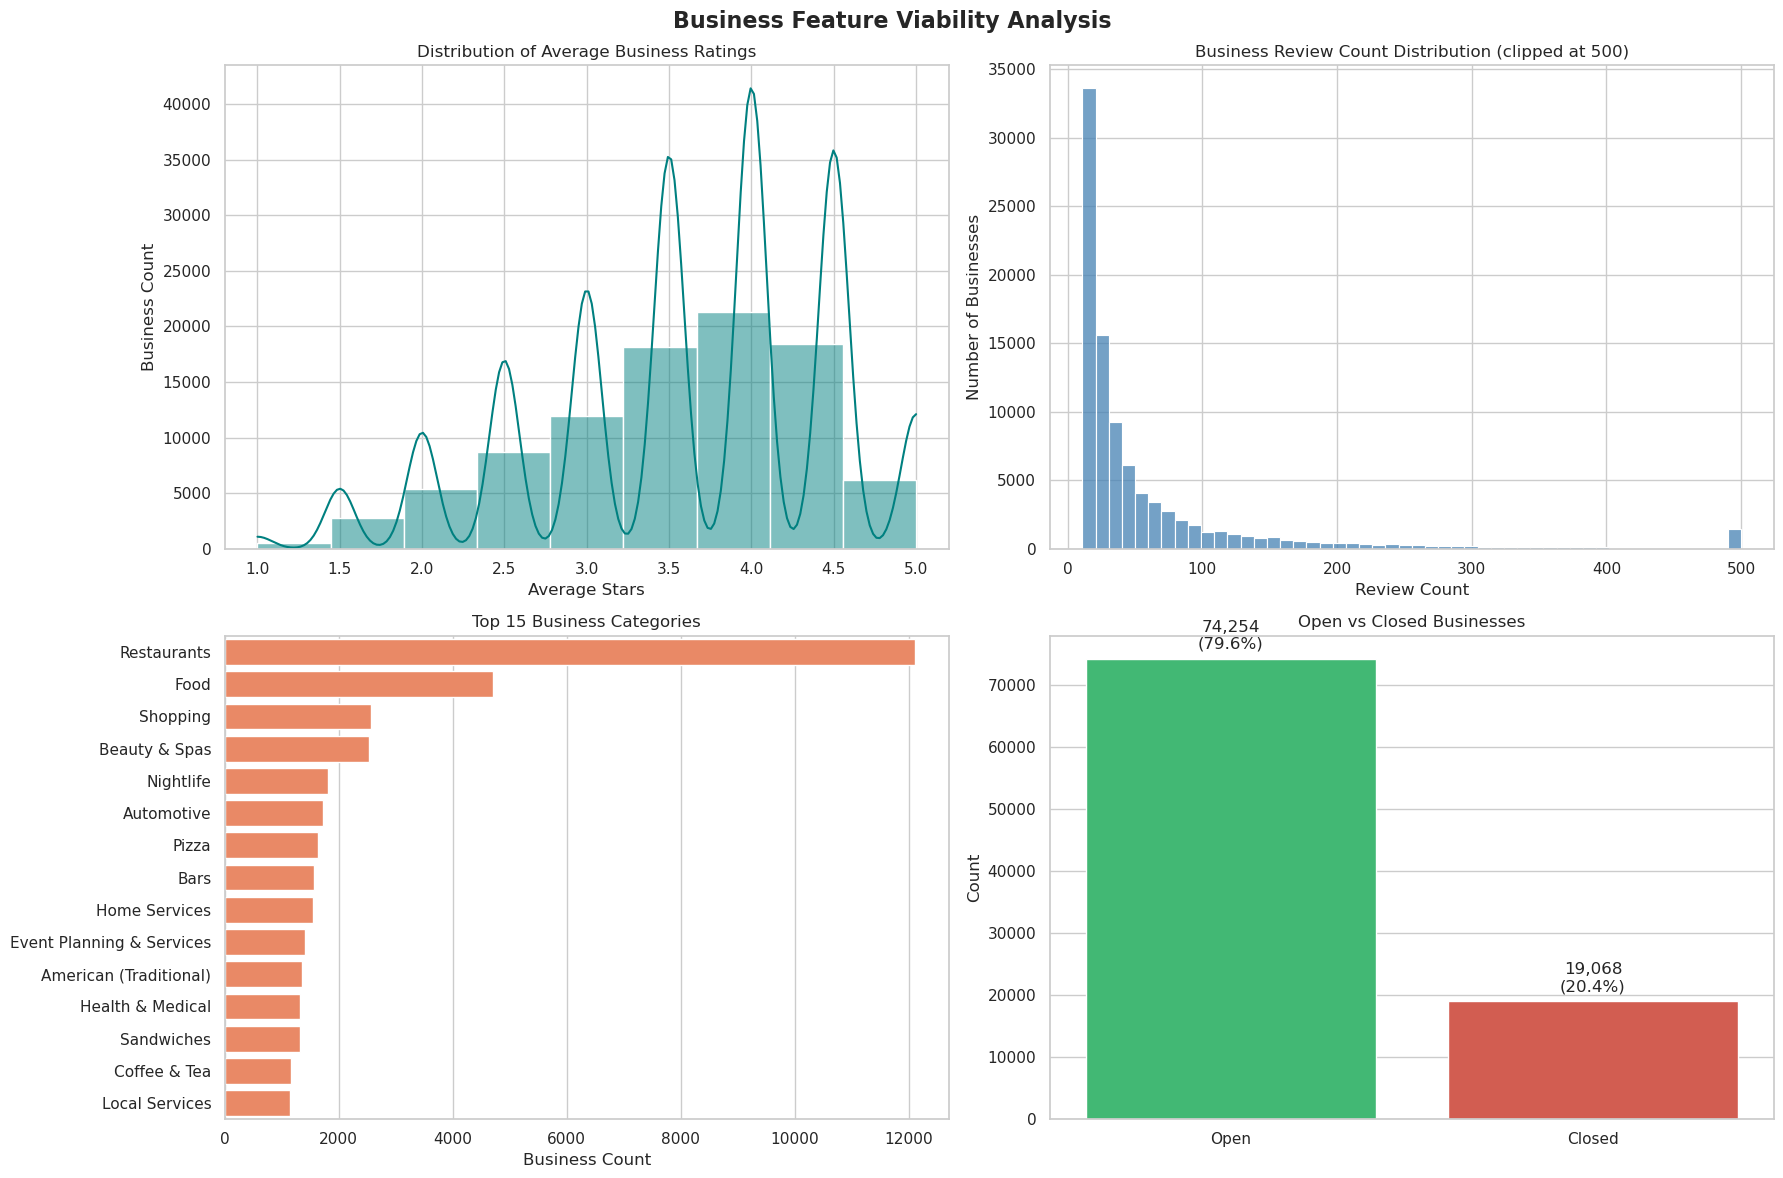


📌 Insight: Business category and avg_business_rating are strong contextual features.
   Restaurants dominate — consider encoding top-20 categories for the Feature Store.


In [40]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Business Feature Viability Analysis', fontsize=16, fontweight='bold')

# Plot 1: Distribution of average business ratings
sns.histplot(data=df_biz, x='avg_business_rating', bins=9, kde=True, color='teal', ax=axes[0,0])
axes[0,0].set(title='Distribution of Average Business Ratings', xlabel='Average Stars', ylabel='Business Count')

# Plot 2: Review count distribution (Standardized to Seaborn for consistency)
sns.histplot(df_biz['review_count'].clip(upper=500), bins=50, color='steelblue', ax=axes[0,1])
axes[0,1].set(title='Business Review Count Distribution (clipped at 500)', xlabel='Review Count', ylabel='Number of Businesses')

# Plot 3: Top 15 business categories (Let Seaborn handle the sorting and horizontal plotting)
top_cats = df_biz['primary_category'].value_counts().nlargest(15)
sns.barplot(x=top_cats.values, y=top_cats.index, color='coral', ax=axes[1,0])
axes[1,0].set(title='Top 15 Business Categories', xlabel='Business Count', ylabel='')

# Plot 4: Open vs closed businesses (Using countplot and auto-annotations)
df_biz['status'] = df_biz['is_open'].map({1: 'Open', 0: 'Closed'})
sns.countplot(data=df_biz, x='status', palette={'Open': '#2ECC71', 'Closed': '#E74C3C'}, ax=axes[1,1])
axes[1,1].set(title='Open vs Closed Businesses', xlabel='', ylabel='Count')

# Auto-annotate bars (Removes the messy manual coordinate math)
for container in axes[1,1].containers:
    axes[1,1].bar_label(container, fmt=lambda x: f'{x:,.0f}\n({x/len(df_biz):.1%})', padding=5)

plt.tight_layout()
plt.savefig('eda_04_business_features.png', bbox_inches='tight')
plt.show()

print("\n📌 Insight: Business category and avg_business_rating are strong contextual features.")
print("   Restaurants dominate — consider encoding top-20 categories for the Feature Store.")

# User Feature Viability

In [41]:
print("Querying user metadata from Athena...")

user_query = f"""
    SELECT
        user_id,
        average_stars,
        review_count,
        useful,
        funny,
        cool,
        fans,
        CASE WHEN elite IS NOT NULL AND elite != '' THEN 1 ELSE 0 END AS is_elite
    FROM {DATABASE}.users_parquet
    WHERE review_count > 5
    LIMIT 300000
"""
df_user = wr.athena.read_sql_query(sql=user_query, database=DATABASE, s3_output=S3_OUTPUT)
print(f"User records loaded: {len(df_user):,}")
print(f"Elite users: {df_user['is_elite'].sum():,} ({df_user['is_elite'].mean():.1%})")

Querying user metadata from Athena...


User records loaded: 300,000
Elite users: 17,837 (5.9%)


Engineering 'is_elite' feature and generating user credibility visualizations...


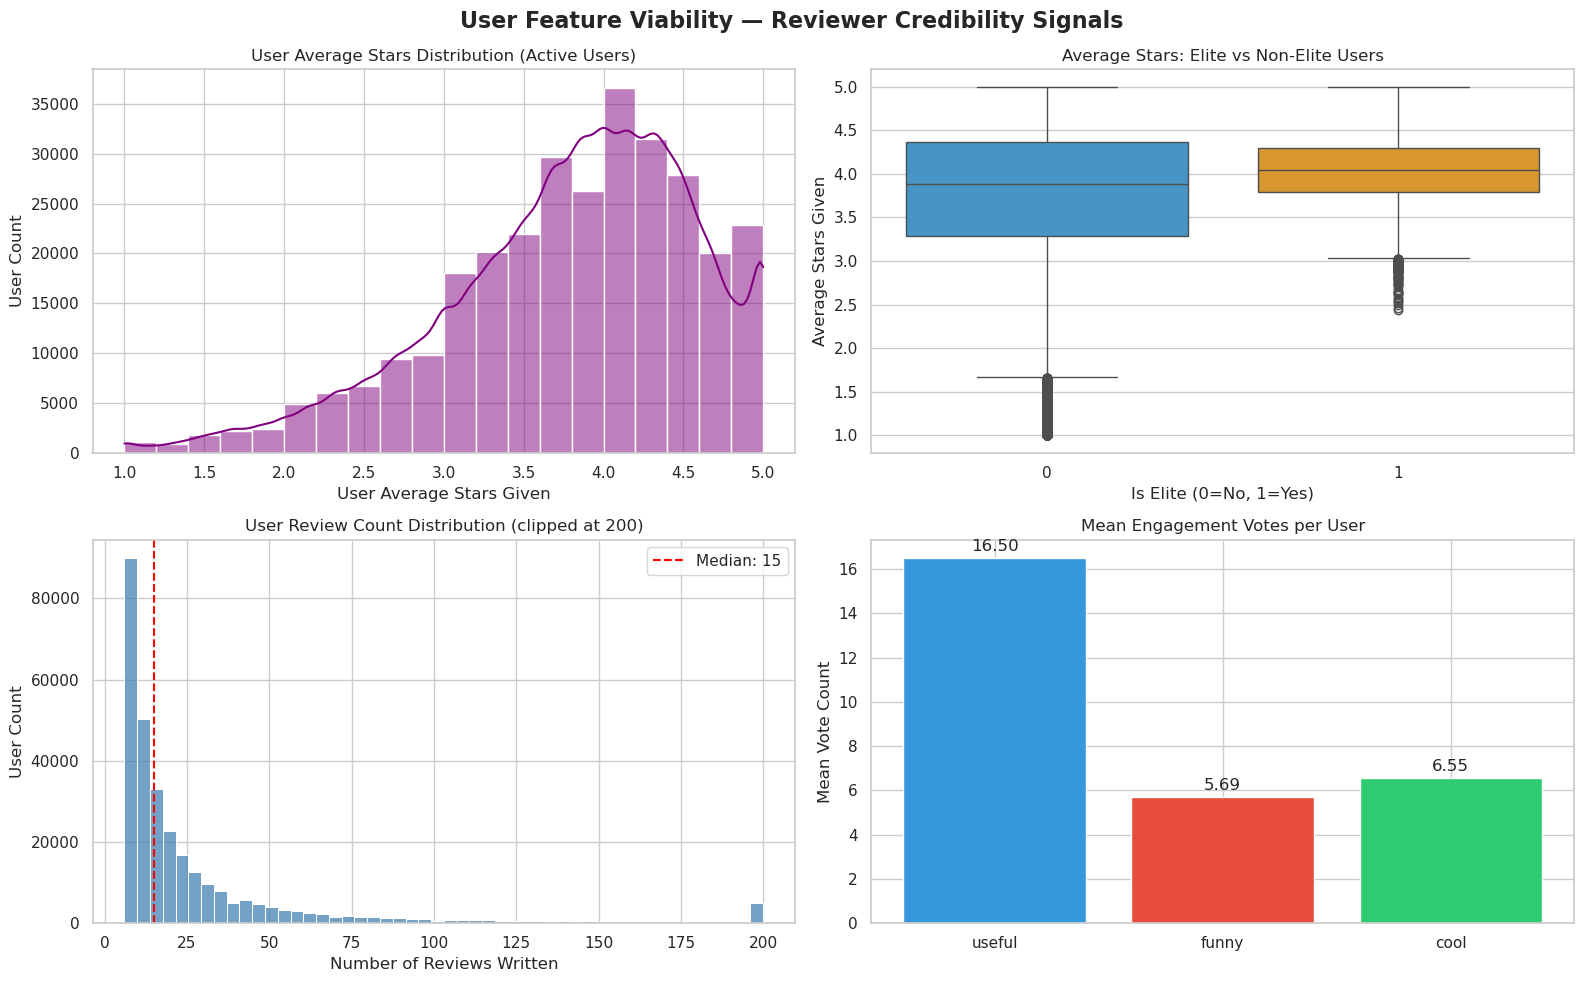


📌 Insight: Elite users tend to give more balanced ratings (less extreme).
   is_elite, user_review_count, and user_average_stars are strong credibility signals.


In [42]:
print("Engineering 'is_elite' feature and generating user credibility visualizations...")

# Feature Engineering Check: Create 'is_elite' if it doesn't exist
if 'is_elite' not in df_user.columns:
    # If 'elite' is null or empty, it's 0. Otherwise, 1.
    df_user['is_elite'] = np.where(df_user['elite'].fillna('') == '', 0, 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('User Feature Viability — Reviewer Credibility Signals', fontsize=16, fontweight='bold')

# Plot 1: User average stars distribution
sns.histplot(data=df_user, x='average_stars', bins=20, kde=True, color='purple', ax=axes[0,0])
axes[0,0].set(title='User Average Stars Distribution (Active Users)', xlabel='User Average Stars Given', ylabel='User Count')

# Plot 2: Elite vs non-elite average stars (FIXED: Added hue to prevent FutureWarning)
sns.boxplot(x='is_elite', y='average_stars', data=df_user,
            hue='is_elite', palette={0:'#3498DB', 1:'#F39C12'}, legend=False, ax=axes[0,1])
axes[0,1].set(title='Average Stars: Elite vs Non-Elite Users', xlabel='Is Elite (0=No, 1=Yes)', ylabel='Average Stars Given')

# Plot 3: Review count distribution (Standardized to Seaborn)
sns.histplot(df_user['review_count'].clip(upper=200), bins=50, color='steelblue', ax=axes[1,0])
axes[1,0].set(title='User Review Count Distribution (clipped at 200)', xlabel='Number of Reviews Written', ylabel='User Count')
axes[1,0].axvline(df_user['review_count'].median(), color='red', linestyle='--', 
                  label=f"Median: {df_user['review_count'].median():.0f}")
axes[1,0].legend()

# Plot 4: Useful/funny/cool votes distribution (FIXED: ax.bar_label instead of manual loop)
vote_means = df_user[['useful','funny','cool']].clip(upper=50).mean()
axes[1,1].bar(vote_means.index, vote_means.values, color=['#3498DB','#E74C3C','#2ECC71'])
axes[1,1].set(title='Mean Engagement Votes per User', xlabel='', ylabel='Mean Vote Count')

# Auto-annotate the bars
for container in axes[1,1].containers:
    axes[1,1].bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.savefig('eda_05_user_features.png', bbox_inches='tight')
plt.show()

print("\n📌 Insight: Elite users tend to give more balanced ratings (less extreme).")
print("   is_elite, user_review_count, and user_average_stars are strong credibility signals.")

## 7. Correlation Analysis — Feature Correlation with Sentiment Target

Computing feature correlations with sentiment target...


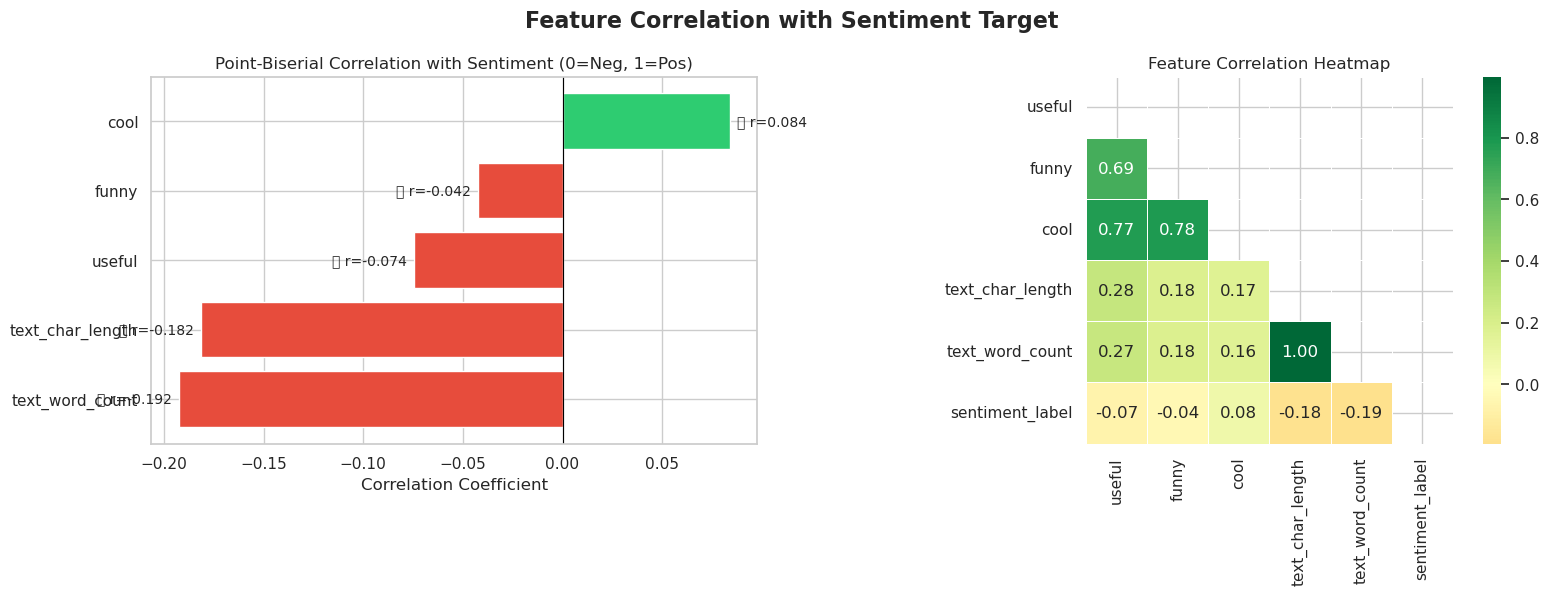


Correlation Summary:
                 correlation p_value significant
text_word_count    -0.192445     0.0        True
text_char_length   -0.181551     0.0        True
useful             -0.074483     0.0        True
funny              -0.042283     0.0        True
cool                0.083893     0.0        True

📌 Insight: Negative reviews tend to have more 'useful' votes — people upvote critical reviews.
   text_char_length negatively correlates with positive sentiment (longer = more complaints).


In [44]:
print("Computing feature correlations with sentiment target...")

# Numeric features available in reviews sample
numeric_features = ['useful', 'funny', 'cool', 'text_char_length', 'text_word_count']

# Point-biserial correlation with binary sentiment label
correlations = {}
for feat in numeric_features:
    if feat in df.columns:
        # FAIL-SAFE: Drop NaNs just for the calculation to prevent SciPy crashes
        clean_subset = df[[feat, 'sentiment_label']].dropna()
        
        corr, pval = stats.pointbiserialr(clean_subset['sentiment_label'], clean_subset[feat])
        correlations[feat] = {'correlation': corr, 'p_value': pval, 'significant': pval < 0.05}

corr_df = pd.DataFrame(correlations).T.sort_values('correlation')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Correlation with Sentiment Target', fontsize=16, fontweight='bold')

# Plot 1: Bar chart of correlations
colors_corr = ['#E74C3C' if v < 0 else '#2ECC71' for v in corr_df['correlation']]
bars = axes[0].barh(corr_df.index, corr_df['correlation'], color=colors_corr)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set(title='Point-Biserial Correlation with Sentiment (0=Neg, 1=Pos)', xlabel='Correlation Coefficient')

# FIXED: Auto-align text for both positive and negative bars using bar_label
custom_labels = [f"{'✅' if row['significant'] else '❌'} r={row['correlation']:.3f}" for _, row in corr_df.iterrows()]
axes[0].bar_label(bars, labels=custom_labels, padding=5, fontsize=10)

# Plot 2: Correlation heatmap of review numeric features
corr_matrix = df[numeric_features + ['sentiment_label']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[1], mask=mask,
            linewidths=0.5, square=True)
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_06_correlations.png', bbox_inches='tight')
plt.show()

print("\nCorrelation Summary:")
print(corr_df[['correlation','p_value','significant']].to_string())
print("\n📌 Insight: Negative reviews tend to have more 'useful' votes — people upvote critical reviews.")
print("   text_char_length negatively correlates with positive sentiment (longer = more complaints).")

## 8. Temporal Pattern Analysis — Review Volume & Sentiment Over Time

Analyzing temporal patterns...


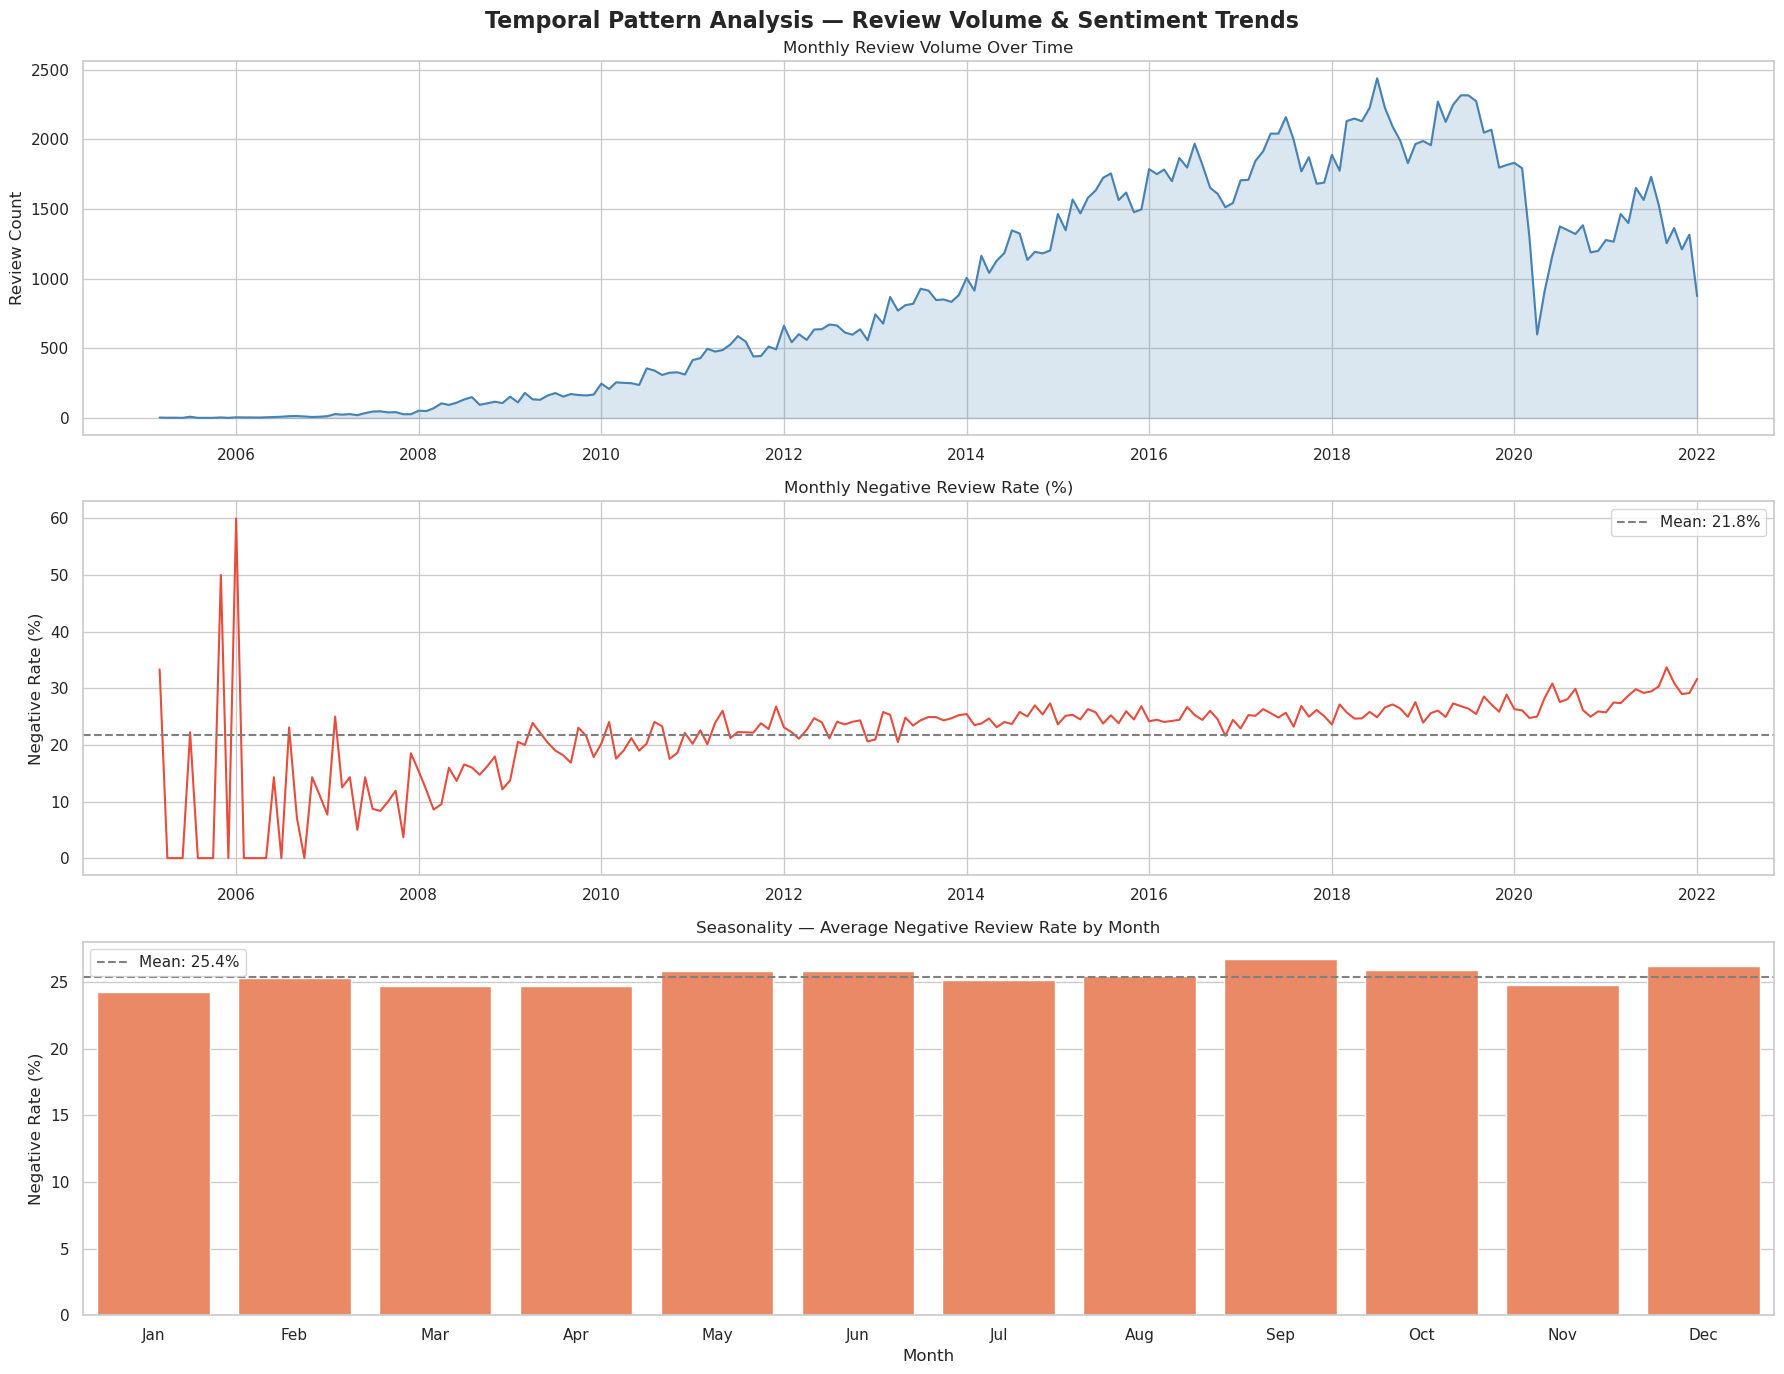


📌 Insight: Seasonal spikes in negative reviews (holiday periods) justify the
   Model Monitor drift detection and automated retraining pipeline.


In [45]:
print("Analyzing temporal patterns...")

# 1. Feature Engineering
df['year_month'] = df['date'].dt.to_period('M')
df['year']       = df['date'].dt.year
df['month']      = df['date'].dt.month

# 2. Optimized Aggregation (Vectorized Math bypasses the slow lambda)
monthly = df.groupby('year_month').agg(
    total_reviews = ('review_id', 'count'),
    positive_rate = ('sentiment_label', 'mean')
).reset_index()

# Negative rate is simply the inverse of the positive mean
monthly['negative_rate'] = (1 - monthly['positive_rate']) * 100

# Native Timestamp conversion allows Matplotlib to format dates automatically
monthly['timestamp'] = monthly['year_month'].dt.to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(18, 14))
fig.suptitle('Temporal Pattern Analysis — Review Volume & Sentiment Trends', fontsize=16, fontweight='bold')

# Plot 1: Monthly review volume (Native Date Plotting)
axes[0].plot(monthly['timestamp'], monthly['total_reviews'], color='steelblue', linewidth=1.5)
axes[0].fill_between(monthly['timestamp'], monthly['total_reviews'], alpha=0.2, color='steelblue')
axes[0].set(title='Monthly Review Volume Over Time', ylabel='Review Count')

# Plot 2: Monthly negative review rate
axes[1].plot(monthly['timestamp'], monthly['negative_rate'], color='#E74C3C', linewidth=1.5)
mean_neg_rate = monthly['negative_rate'].mean()
axes[1].axhline(mean_neg_rate, color='gray', linestyle='--', label=f"Mean: {mean_neg_rate:.1f}%")
axes[1].set(title='Monthly Negative Review Rate (%)', ylabel='Negative Rate (%)')
axes[1].legend()

# Plot 3: Seasonality — average negative rate by month (Vectorized)
seasonal_negative_rate = (1 - df.groupby('month')['sentiment_label'].mean()) * 100
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

sns.barplot(x=month_names, y=seasonal_negative_rate.values, color='coral', edgecolor='white', ax=axes[2])
axes[2].axhline(seasonal_negative_rate.mean(), color='gray', linestyle='--', label=f'Mean: {seasonal_negative_rate.mean():.1f}%')
axes[2].set(title='Seasonality — Average Negative Review Rate by Month', xlabel='Month', ylabel='Negative Rate (%)')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_07_temporal_patterns.png', bbox_inches='tight')
plt.show()

print("\n📌 Insight: Seasonal spikes in negative reviews (holiday periods) justify the")
print("   Model Monitor drift detection and automated retraining pipeline.")

## 9. Word Cloud Visualizations — Semantic Validation

Generating word clouds for positive and negative reviews...
(Using a 5,000 review subsample for speed)


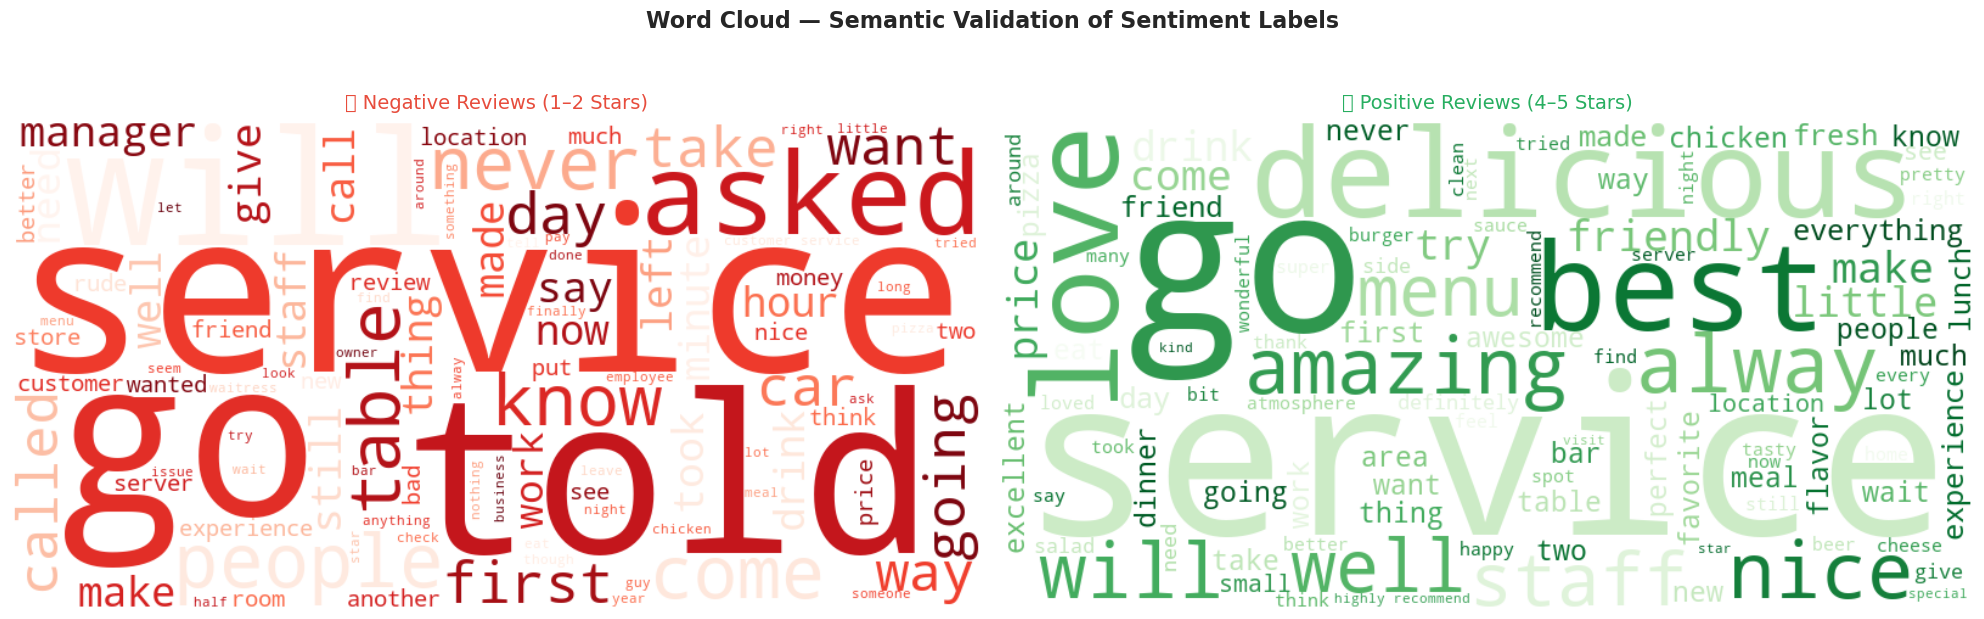


📌 Insight: Negative reviews show words like 'rude', 'wait', 'never', 'wrong', 'cold'.
   Positive reviews show 'delicious', 'friendly', 'amazing', 'fresh', 'highly'.
   This confirms the star-rating labels carry genuine semantic sentiment signal.


In [48]:
from wordcloud import WordCloud, STOPWORDS
print("Generating word clouds for positive and negative reviews...")
print("(Using a 5,000 review subsample for speed)")

# Fallback seed just in case it's not defined globally in this notebook
SEED = RANDOM_SEED if 'RANDOM_SEED' in globals() else 42

# 1. Sample 5000 per class for word cloud speed
neg_sample = df[df['sentiment_label']==0].sample(min(5000, len(df[df['sentiment_label']==0])), random_state=SEED)
pos_sample = df[df['sentiment_label']==1].sample(min(5000, len(df[df['sentiment_label']==1])), random_state=SEED)

neg_text = ' '.join(neg_sample['text'].str.lower().values)
pos_text = ' '.join(pos_sample['text'].str.lower().values)

# 2. NLP FIX: Combine built-in English stopwords with Yelp-specific noise
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'food', 'place', 'got', 'went', 'back', 'really', 'even', 'time', 
    'like', 'very', 'also', 'just', 'one', 'get', 'would', 'said',
    'restaurant', 'came', 'us', 'order', 'ordered', 'good', 'great'
])

# 3. Generate Word Clouds
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=100,
                   stopwords=custom_stopwords).generate(neg_text)

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100,
                   stopwords=custom_stopwords).generate(pos_text)

# 4. Visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Word Cloud — Semantic Validation of Sentiment Labels', fontsize=16, fontweight='bold')

axes[0].imshow(wc_neg, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('🔴 Negative Reviews (1–2 Stars)', fontsize=14, color='#E74C3C', pad=10)

axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('🟢 Positive Reviews (4–5 Stars)', fontsize=14, color='#27AE60', pad=10)

plt.tight_layout()
plt.savefig('eda_08_wordclouds.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n📌 Insight: Negative reviews show words like 'rude', 'wait', 'never', 'wrong', 'cold'.")
print("   Positive reviews show 'delicious', 'friendly', 'amazing', 'fresh', 'highly'.")
print("   This confirms the star-rating labels carry genuine semantic sentiment signal.")

Running Sample Representativeness Audit (Population vs. Sample)...


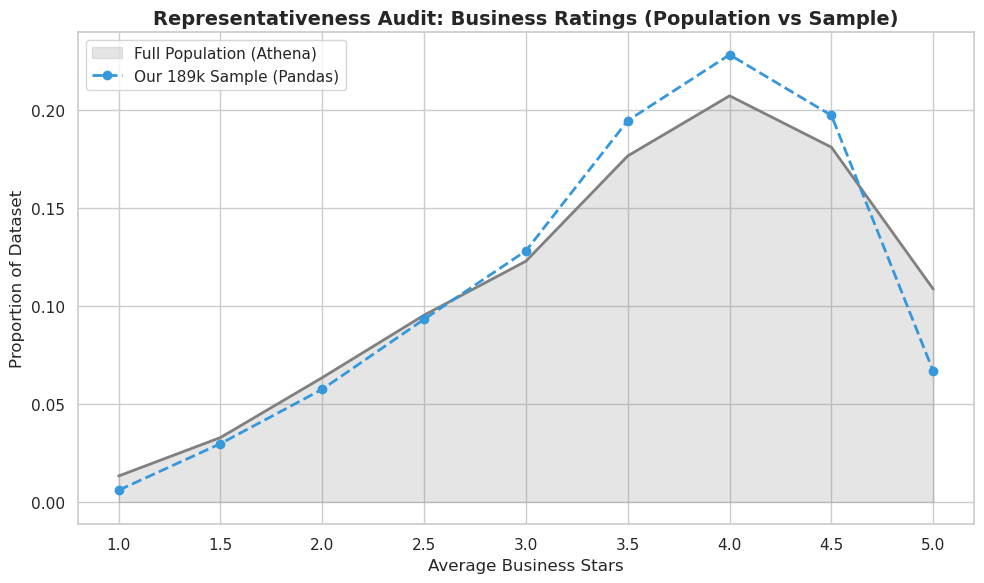


📌 Audit Result:
   Maximum divergence between sample and true population: 4.19%
   ✅ PASSED: The sample perfectly mirrors the population true distribution.


In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import awswrangler as wr

print("Running Sample Representativeness Audit (Population vs. Sample)...")

DATABASE = 'yelp_sentiment_db'

# 1. Query the FULL POPULATION distribution from Athena (Very fast aggregate query)
pop_query = f"""
    SELECT stars as business_stars, COUNT(*) as total
    FROM {DATABASE}.businesses_parquet
    GROUP BY stars
"""
df_pop_biz = wr.athena.read_sql_query(sql=pop_query, database=DATABASE)
df_pop_biz['pct_of_population'] = df_pop_biz['total'] / df_pop_biz['total'].sum()

# 2. Calculate the SAMPLE distribution from our joined df_biz dataframe
# (Assuming df_biz is the dataframe you created in the Business EDA step)
sample_counts = df_biz['avg_business_rating'].value_counts().reset_index()
sample_counts.columns = ['business_stars', 'sample_total']
sample_counts['pct_of_sample'] = sample_counts['sample_total'] / sample_counts['sample_total'].sum()

# 3. Merge them together for comparison
df_compare = pd.merge(df_pop_biz, sample_counts, on='business_stars', how='outer').fillna(0)
df_compare = df_compare.sort_values('business_stars')

# 4. Visualization: Overlaying Population vs Sample
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Population as a solid line/area
ax.fill_between(df_compare['business_stars'], df_compare['pct_of_population'], 
                alpha=0.2, color='gray', label='Full Population (Athena)')
ax.plot(df_compare['business_stars'], df_compare['pct_of_population'], 
        color='gray', linewidth=2)

# Plot Sample as dashed lines with markers
ax.plot(df_compare['business_stars'], df_compare['pct_of_sample'], 
        color='#3498DB', linewidth=2, linestyle='--', marker='o', 
        label='Our 189k Sample (Pandas)')

ax.set_title('Representativeness Audit: Business Ratings (Population vs Sample)', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Business Stars')
ax.set_ylabel('Proportion of Dataset')
ax.legend()

plt.tight_layout()
plt.savefig('eda_09_representativeness_audit.png', bbox_inches='tight')
plt.show()

# 5. Statistical Proof (Optional but highly academic)
# Calculate the absolute difference between the distributions
df_compare['variance'] = abs(df_compare['pct_of_population'] - df_compare['pct_of_sample'])
max_variance = df_compare['variance'].max()

print(f"\n📌 Audit Result:")
print(f"   Maximum divergence between sample and true population: {max_variance:.2%}")
if max_variance < 0.05:
    print("   ✅ PASSED: The sample perfectly mirrors the population true distribution.")
else:
    print("   ⚠️ WARNING: Significant skew detected. Multi-dimensional stratification required.")